In [ ]:
import os
SAVE_FIGS = os.getenv("PHYTOMNI_SAVE") == "1"
if SAVE_FIGS:
    os.makedirs("output", exist_ok=True)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
import plotly.offline as offline

offline.init_notebook_mode(connected=True)
# pio.kaleido.scope.default_format = 'pdf'

sns.set_theme(style="white", font="sans-serif")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.unicode_minus": False,
    "font.sans-serif": ["Arial"],
})

In [5]:
accuracy_data = {
    "model": [
        "DeepSeek-R1",
        "DeepSeek-V3",
        "Claude-Opus-4.1",
        "Gemini-2.5-Pro",
        "GPT-5",
        "Grok-3-Beta",
        "o3",
        "Analyst Agent-PhytoChat",
        "Analyst Agent-PhytoResoner"
    ],
    "accuracy": [
        0.189655,
        0.160920,
        0.155172,
        0.241379,
        0.155172,
        0.471264,
        0.166667,
        0.706897,
        0.724138
    ]
}

accuracy_df = pd.DataFrame(accuracy_data)

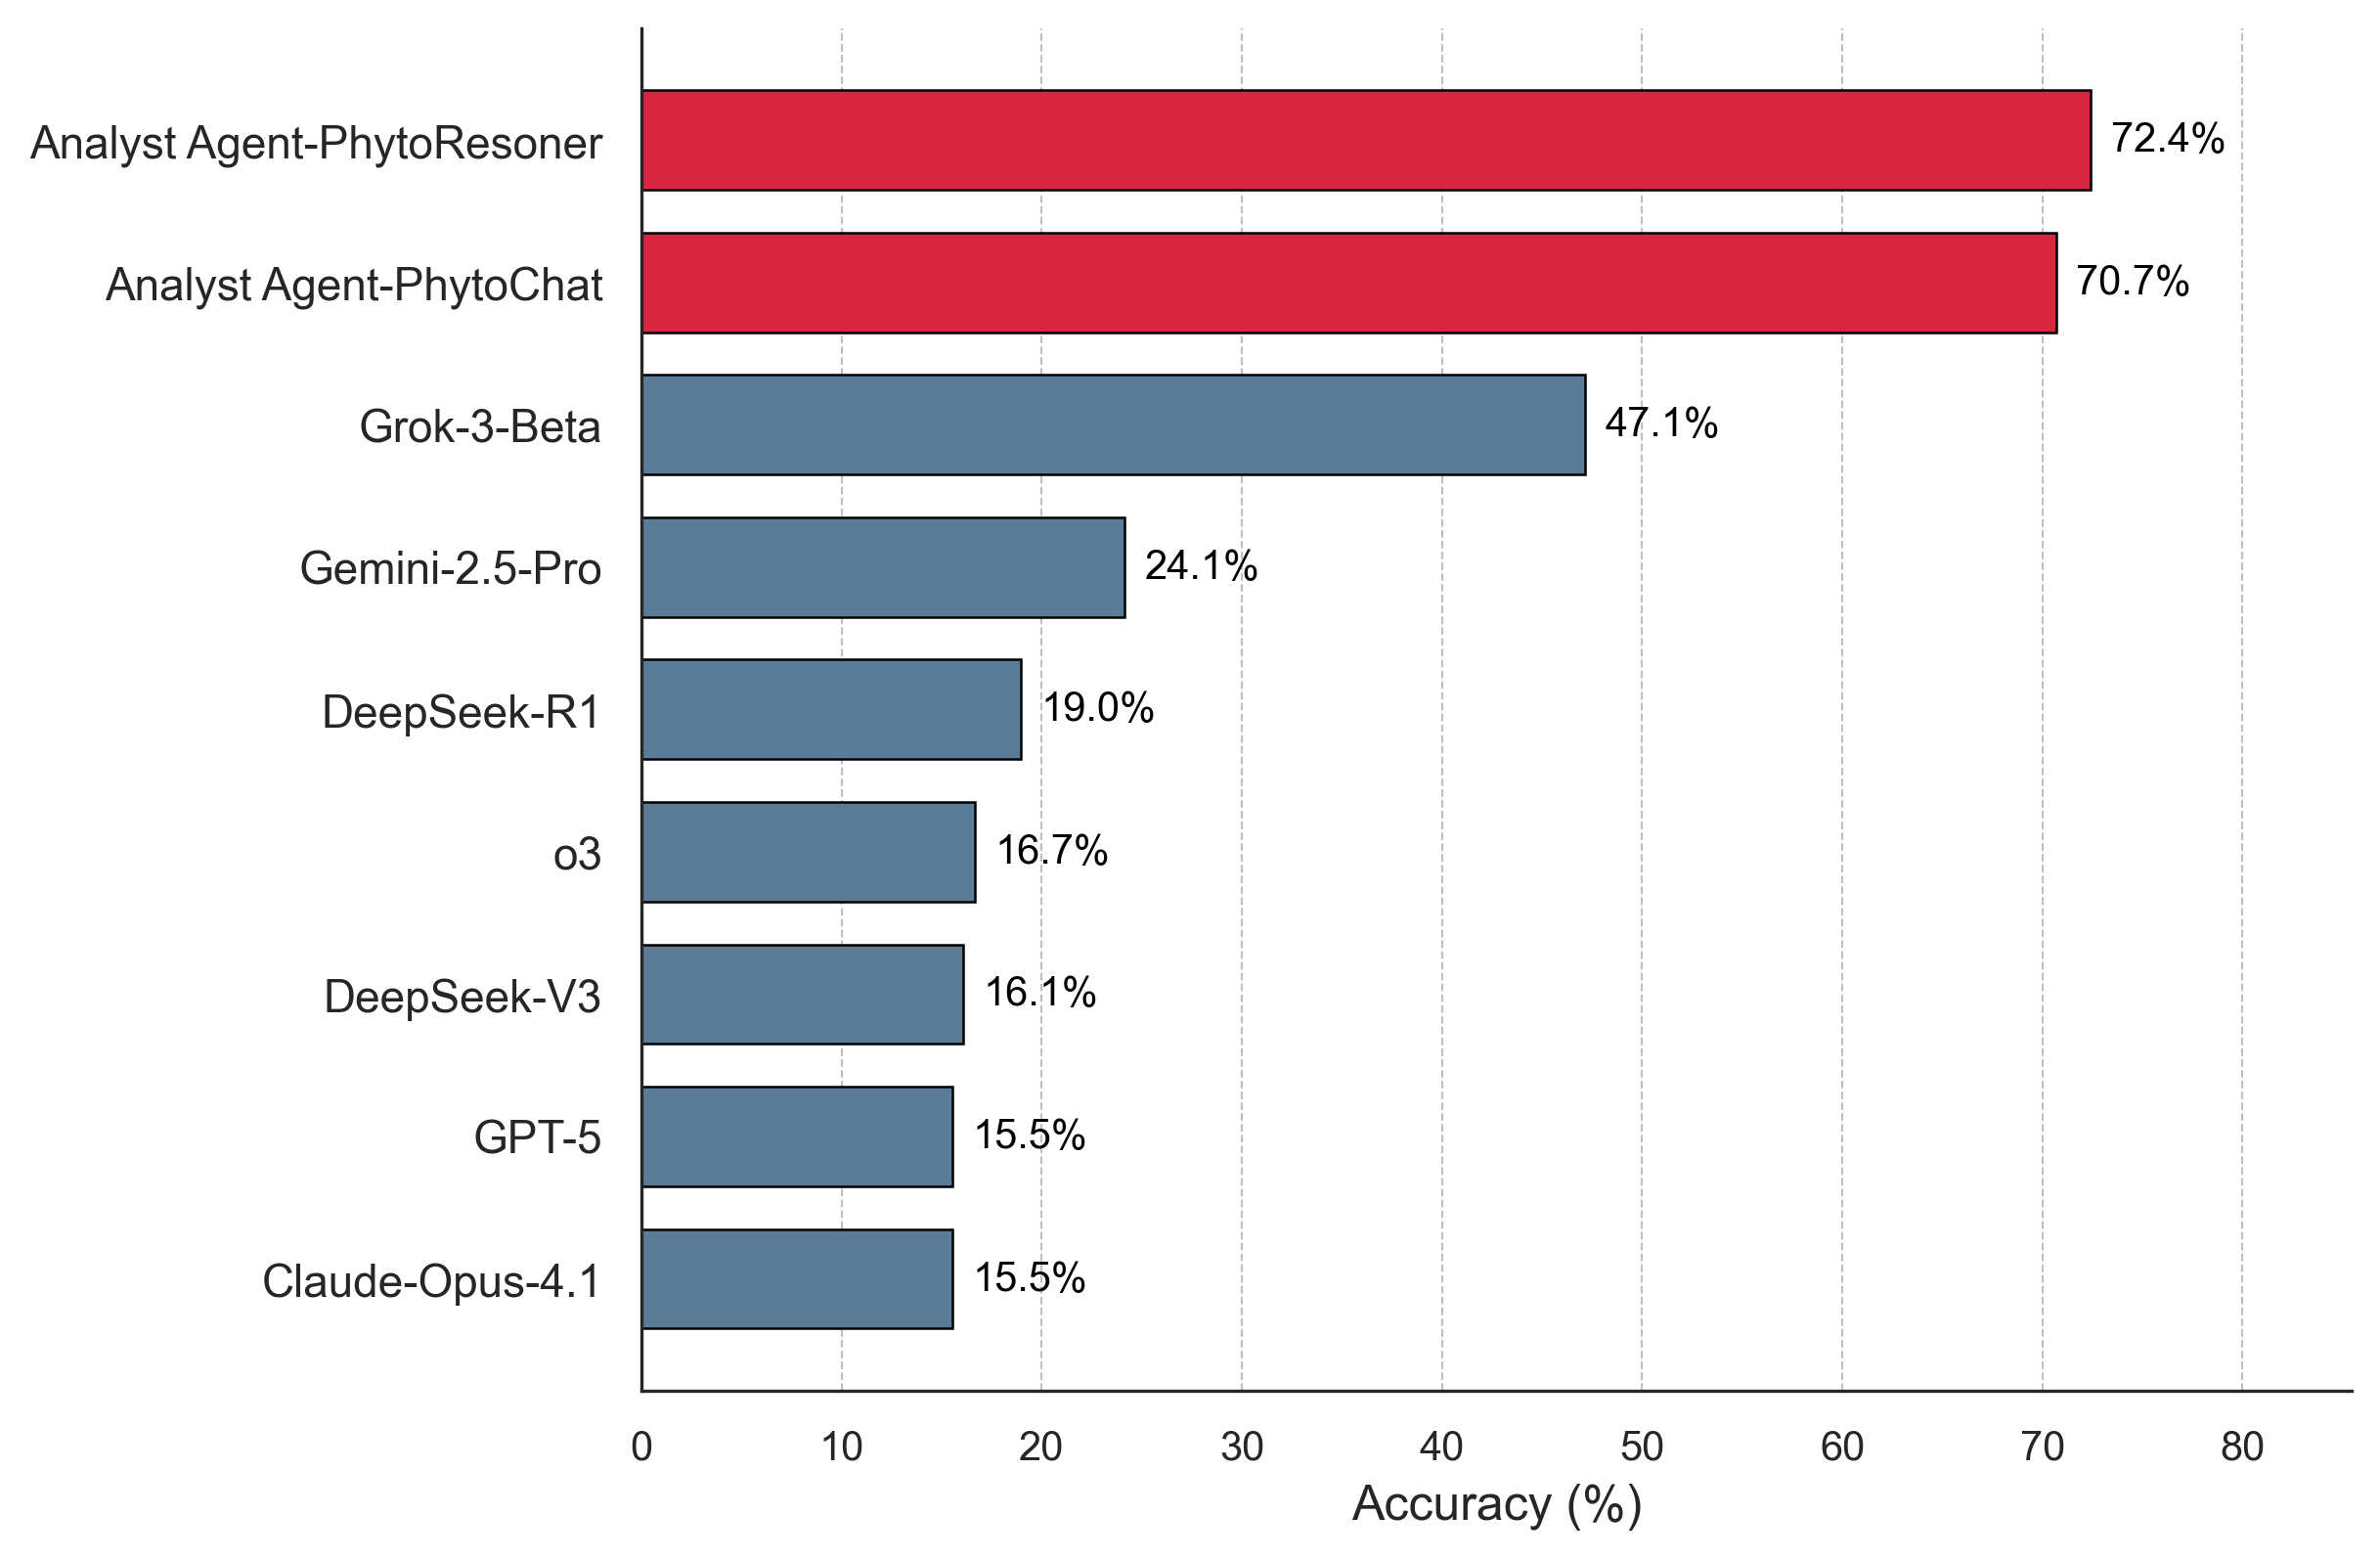

In [6]:
df = accuracy_df.copy()
df["accuracy_pct"] = df["accuracy"] * 100
df = df.sort_values("accuracy_pct", ascending=True).reset_index(drop=True)
agent_color = "#D7263D"
baseline_color = "#5B7C99"
colors = [agent_color if "Agent" in m else baseline_color for m in df["model"]]

fig, ax = plt.subplots(figsize=(8, 5.2), dpi=300, constrained_layout=True)

bars = ax.barh(
    df["model"], df["accuracy_pct"],
    color=colors, edgecolor="black", linewidth=0.6, height=0.7,
)

for bar, v in zip(bars, df["accuracy_pct"]):
    ax.text(
        bar.get_width() + 1.0, bar.get_y() + bar.get_height() / 2,
        f"{v:.1f}%", va="center", ha="left", fontsize=10, color="black",
    )

ax.set_xlim(0, df["accuracy_pct"].max() * 1.18)
ax.set_xlabel("Accuracy (%)", fontsize=12)
ax.set_ylabel("")

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)
ax.tick_params(axis="y", labelsize=11)
ax.tick_params(axis="x", labelsize=10)

ax.xaxis.grid(True, linestyle="--", linewidth=0.5, color="gray", alpha=0.5)
ax.set_axisbelow(True)

if SAVE_FIGS:
    fig.savefig("output/supplementary_fig.19.pdf", bbox_inches="tight")
plt.show()